# Introduction

# Setup


## Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.decomposition import PCA

from datasets import load_dataset

import nltk
from nltk.tokenize import word_tokenize

import gensim.downloader as api

### WandDB

# Preprocessing

## Data Loading

In [2]:
ds = load_dataset("tau/commonsense_qa")

README.md:   0%|          | 0.00/7.39k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9741 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1221 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1140 [00:00<?, ? examples/s]

## Tokenization

In [9]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/timon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
def tokenize(text):
    return word_tokenize(text)  # Handles punctuation better

## Word Embedding

Each word in the question and answer choices is mapped to its corresponding vector. 

For instance, in the question “What is the capital of France?” with choices `[“Paris”, “London”, “Berlin”, “Madrid”]`, words like “capital” and “Paris” would have embeddings reflecting their semantic properties.

In [12]:
wv = api.load('word2vec-google-news-300')

For the question “What is the capital of France?”, the embeddings of `[“What”, “is”, “the”, “capital”, “of”, “France”]` are aggregated to form a single vector encapsulating the question’s semantics. 

Similarly, each answer choice `[“Paris”, “London”, “Berlin”, “Madrid”]` is represented by its respective vector.

In [ ]:
def vectorize_text(text):
    # TODO
    pass

# Model

## WordEmbedding Classifier

In [ ]:
# Hyperparameters
EMBEDDING_DIM = 300
HIDDEN_DIM = 128
NUM_CLASSES = 5  # CommonsenseQA has 5 answer choices
EPOCHS = 10
BATCH_SIZE = 16
LR = 0.001

class WordEmbeddingClassifier(nn.Module):
    def __init__(self, input_dim=600, hidden_dim=128, output_dim=1):
        super(WordEmbeddingClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)  # Single score per choice

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)  # No softmax here, as we use CrossEntropyLoss
        return x

# Training

# Evaluation

# Interpretation

## Word Embedding

In [13]:
def display_scatterplot(model, words): # assumes all words are in the vocabulary
    word_vectors = [model[word] for word in words]
    twodim = PCA().fit_transform(word_vectors)[:,:2]
    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x + 0.03, y + 0.03, word)

['What', 'is', 'the', 'capital', 'France']


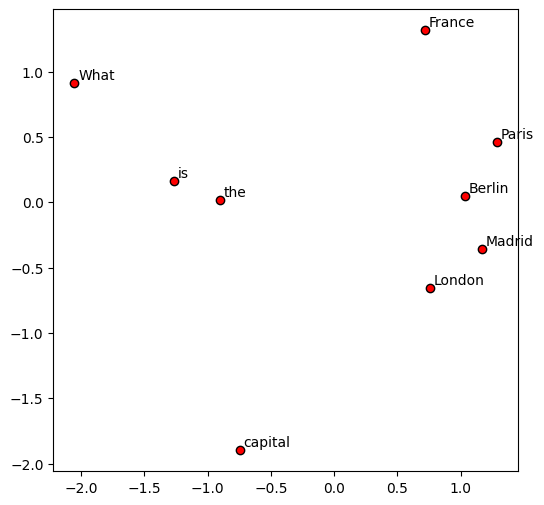

In [ ]:
question = 'What is the capital of France?'
question_tokens = tokenize(question)

print(question_tokens)

display_scatterplot(wv, [
        *question_tokens, # Question
        'Paris', 'London', 'Berlin', 'Madrid' # Choices 
    ])